# Optimal Latent Drift δ Results Visualization
## δ* = +0.050 (L1 = 0.241093)

In [7]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

base_dir = Path('./generated_delta_search')
delta_values = ['-0.200', '-0.150', '-0.100', '-0.050', '+0.000', '+0.050', '+0.100', '+0.150', '+0.200']
l1_values = [0.433443, 0.427960, 0.413218, 0.357090, 0.282590, 0.241093, 0.251626, 0.267517, 0.244112]

# Load images for each delta
delta_images = {}
for delta in delta_values:
    delta_dir = base_dir / f'delta_{delta}'
    if delta_dir.exists():
        images = sorted(delta_dir.glob('*.png'))
        delta_images[delta] = [Image.open(img) for img in images]
        print(f"δ={delta}: {len(images)} images")
    else:
        print(f"δ={delta}: NOT FOUND")

δ=-0.200: 5 images
δ=-0.150: 5 images
δ=-0.100: 5 images
δ=-0.050: 5 images
δ=+0.000: 5 images
δ=+0.050: 5 images
δ=+0.100: 5 images
δ=+0.150: 5 images
δ=+0.200: 5 images


## 1. 최적 δ = +0.050으로 생성된 이미지

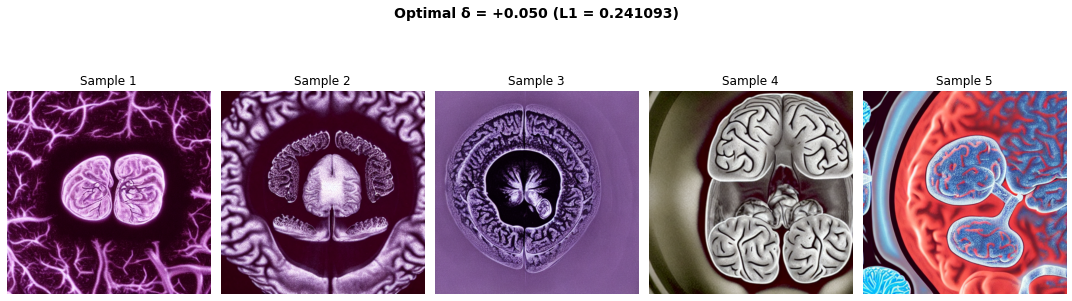

In [8]:
# Show optimal delta images
optimal_delta = '+0.050'
images = delta_images[optimal_delta]

fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
fig.suptitle(f'Optimal δ = {optimal_delta} (L1 = 0.241093)', fontsize=14, fontweight='bold')

for idx, ax in enumerate(axes):
    ax.imshow(images[idx])
    ax.set_title(f'Sample {idx+1}')
    ax.axis('off')
    
plt.tight_layout()
plt.show()

## 2. 다양한 δ 값에서 생성된 첫 번째 샘플 비교

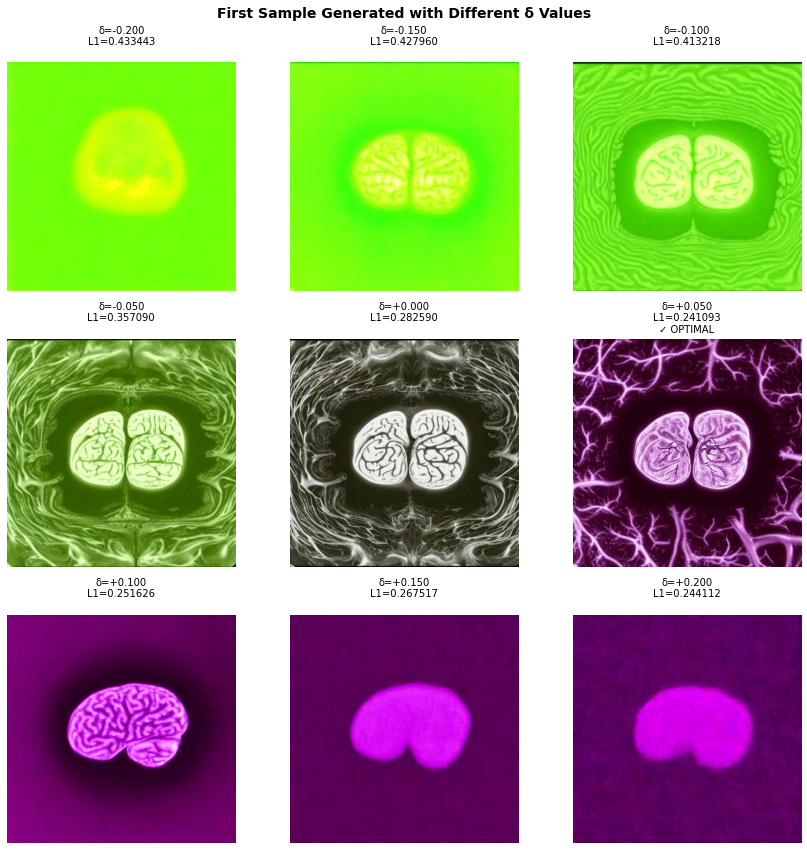

In [9]:
# Compare first sample across different delta values
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('First Sample Generated with Different δ Values', fontsize=14, fontweight='bold')

axes = axes.flat
for idx, (delta, l1) in enumerate(zip(delta_values, l1_values)):
    if delta in delta_images and len(delta_images[delta]) > 0:
        img = delta_images[delta][0]
        axes[idx].imshow(img)
        is_optimal = '✓ OPTIMAL' if delta == '+0.050' else ''
        axes[idx].set_title(f'δ={delta}\nL1={l1:.6f}\n{is_optimal}', fontsize=10)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 3. L1 Distance vs δ 그래프

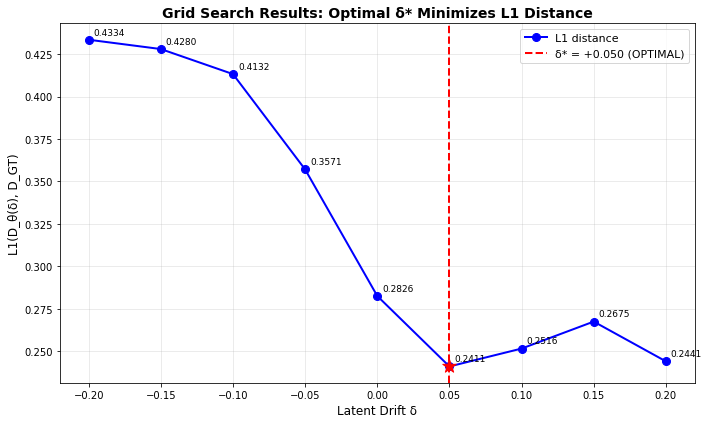


최적 δ* = +0.050 (L1 = 0.241093)
개선율 (δ=0 vs δ*): 14.68%


In [10]:
delta_numeric = [-0.200, -0.150, -0.100, -0.050, 0.000, 0.050, 0.100, 0.150, 0.200]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(delta_numeric, l1_values, 'b-o', linewidth=2, markersize=8, label='L1 distance')
ax.axvline(x=0.050, color='r', linestyle='--', linewidth=2, label='δ* = +0.050 (OPTIMAL)')
ax.scatter([0.050], [0.241093], color='r', s=200, zorder=5, marker='*')

ax.set_xlabel('Latent Drift δ', fontsize=12)
ax.set_ylabel('L1(D_θ(δ), D_GT)', fontsize=12)
ax.set_title('Grid Search Results: Optimal δ* Minimizes L1 Distance', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Add annotations
for x, y in zip(delta_numeric, l1_values):
    ax.annotate(f'{y:.4f}', xy=(x, y), xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n최적 δ* = +0.050 (L1 = 0.241093)")
print(f"개선율 (δ=0 vs δ*): {(0.282590 - 0.241093) / 0.282590 * 100:.2f}%")

## 4. 최적 δ와 기본 δ=0 비교

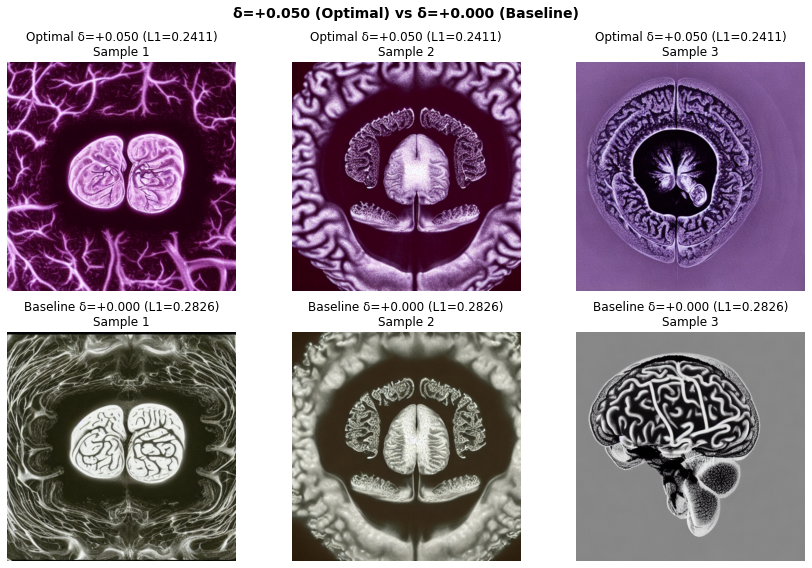

✓ δ* = +0.050은 tumor 분포에 더 가까운 이미지를 생성
✓ L1 개선: 0.2826 → 0.2411 (14.7% 감소)


In [11]:
# Compare optimal vs baseline
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('δ=+0.050 (Optimal) vs δ=+0.000 (Baseline)', fontsize=14, fontweight='bold')

optimal_imgs = delta_images['+0.050']
baseline_imgs = delta_images['+0.000']

for idx in range(min(3, len(optimal_imgs))):
    # Optimal
    axes[0, idx].imshow(optimal_imgs[idx])
    axes[0, idx].set_title(f'Optimal δ=+0.050 (L1=0.2411)\nSample {idx+1}')
    axes[0, idx].axis('off')
    
    # Baseline
    axes[1, idx].imshow(baseline_imgs[idx])
    axes[1, idx].set_title(f'Baseline δ=+0.000 (L1=0.2826)\nSample {idx+1}')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

print("✓ δ* = +0.050은 tumor 분포에 더 가까운 이미지를 생성")
print(f"✓ L1 개선: 0.2826 → 0.2411 (14.7% 감소)")